# BANK MARKETING ANALYSIS — FROM DATA TO DECISION

>Data source: BANK_MARKETING_CAMPAIGN_UCI

## Executive Summary

>Mục tiêu:
 của dự án là xây dựng một hệ thống dự đoán khả năng khách hàng đăng ký sản phẩm ngân hàng, đồng thời tối ưu quyết định gọi điện nhằm tối đa hóa lợi nhuận chiến dịch marketing.

### Cách tiếp cận

- Thực hiện EDA để tìm insight hành vi khách hàng
- Kiểm định giả thuyết bằng các phương pháp thống kê (t-test, chi-square)
- Xây dựng mô hình Random Forest kết hợp Calibration để dự đoán xác suất chính xác hơn
- Thiết kế Decision Engine dựa trên Expected Profit

### Điểm nổi bật

- Phát hiện và loại bỏ Data Leakage (biến duration)
- Áp dụng Calibration để biến xác suất thành usable business signal
- Chuyển bài toán từ classification → decision optimization

### Kết quả

- Tăng tỷ lệ chuyển đổi từ ~11% lên ~25%
- Ước tính lợi nhuận tăng thêm: **$140,000 / 10,000 khách hàng**

### Giá trị mang lại

>Hệ thống không chỉ dự đoán, mà còn hỗ trợ doanh nghiệp:

- Giảm chi phí gọi điện không hiệu quả
- Tối ưu nguồn lực telesales
- Ra quyết định dựa trên dữ liệu

Dự án đi theo trình tự:
>Data → EDA → Insight → Hypothesis → Validation → Model → Decision → Action → Profit

---

## ❓ Key Questions
1. Khách hàng nào dễ convert?
2. Feature nào ảnh hưởng mạnh nhất?
3. Có thể chia nhóm khách hàng không?
4. Làm sao tối ưu campaign?

---
## Phần 1: Khám phá dữ liệu

### 1.1. Thiết lập và thêm thư viện

In [68]:
# code
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("Set2")

# Stats
from scipy.stats import ttest_ind, chi2_contingency

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Clustering
from sklearn.cluster import KMeans

### 1.2. Load Data

In [69]:
df = pd.read_csv("bank-additional-full.csv", sep=";")
df.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [70]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


### 1.3. Hiểu dữ liệu 

## Kiểm tra chất lượng dữ liệu

### 🎯 Mục tiêu
Đảm bảo dữ liệu:
- Không bị thiếu (missing values)
- Không bị trùng lặp
- Không có vấn đề nghiêm trọng về phân phối


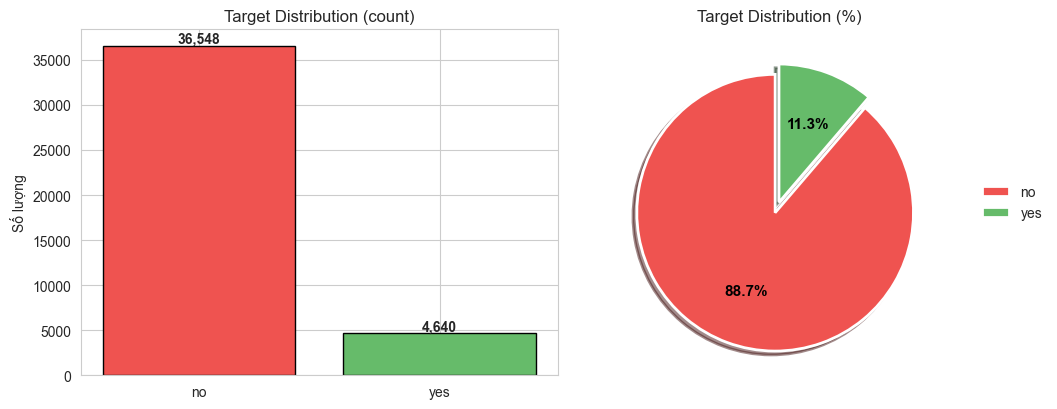

In [71]:
counts = df["y"].value_counts().sort_index()
labels = ["no", "yes"]
colors = ["#EF5350", "#66BB6A"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

bars = axes[0].bar(labels, counts.values, color=colors, edgecolor="black")
axes[0].set_title("Target Distribution (count)")
axes[0].set_ylabel("Số lượng")
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h, f"{int(h):,}", ha="center", va="bottom", fontsize=10, fontweight="bold")

explode = (0.08, 0)
wedges, texts, autotexts = axes[1].pie(
    counts.values,
    labels=None,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    explode=explode,
    shadow=True,
    wedgeprops=dict(edgecolor="white", linewidth=2)
)
axes[1].set_title("Target Distribution (%)")
axes[1].legend(wedges, labels, loc="center left", bbox_to_anchor=(1.05, 0.5), frameon=False)

for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight("bold")
    t.set_color("black")

plt.tight_layout()
plt.show()


### Key Insights

#### 1. Mất cân bằng nghiêm trọng 
- Nhóm **"No" chiếm đa số tuyệt đối**, trong khi nhóm **"Yes" rất nhỏ**
- Điều này cho thấy:
  - Phần lớn khách hàng **không đăng ký dịch vụ**
  - Conversion rate của chiến dịch là **thấp**


#### 2. Tác động trên mô hình
- Accuracy sẽ **không còn đáng tin cậy**
  - Ví dụ: model luôn đoán "No" vẫn có accuracy cao
- Cần sử dụng:
  - **F1-score**
  - **ROC-AUC**
  - **Precision / Recall**


#### 3. Business Interpretation
- Chiến dịch hiện tại:
  - **hiệu quả chưa cao**
  - đang tốn tài nguyên vào nhóm không convert

#### 4. Opportunity
- Nhóm "Yes":
  - là **target quan trọng nhất**
  - cần hiểu sâu:
    - họ là ai?
    - có đặc điểm gì khác biệt?

### Summary
Dataset **mất cân bằng nghiêm trọng**,  
→ cần:
- điều chỉnh cách đánh giá model  
- tập trung phân tích sâu vào nhóm khách hàng có khả năng convert

### Kiểm tra giá trị thiếu 

In [72]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df[missing_df["Missing Count"] > 0]

,Missing Count,Missing %


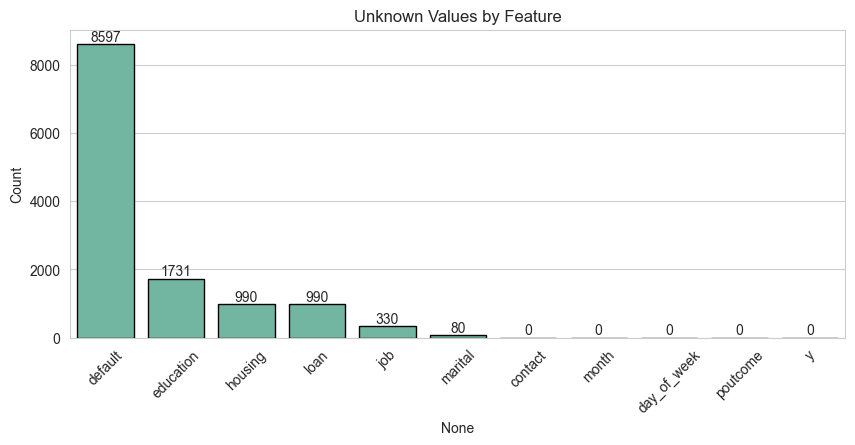

In [73]:
unknown_counts = {}

for col in df.select_dtypes(include='object').columns:
    unknown_counts[col] = (df[col] == 'unknown').sum()

unknown_df = pd.Series(unknown_counts).sort_values(ascending=False)

plt.figure(figsize=(10,4))
sns.barplot(x=unknown_df.index, y=unknown_df.values, edgecolor='black')

plt.title("Unknown Values by Feature")
plt.xticks(rotation=45)
plt.ylabel("Count")

for i, v in enumerate(unknown_df.values):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.show()

## Key Insights — Giá trị thiếu bị ẩn 
### 🎯 Observation
Mặc dù dataset không có missing values rõ ràng,  
nhưng nhiều biến categorical chứa giá trị `"unknown"`.

### 📊 Summary

| Feature   | Unknown Count | Nhận xét |
|----------|-------------|--------|
| default  | rất cao     | ⚠️ cần xử lý |
| education| trung bình  | cần cân nhắc |
| job      | thấp        | chấp nhận được |
| housing  | thấp        | chấp nhận được |

### 1. `default` không đáng tin cậy
- Tỷ lệ unknown rất cao (~20%)
→ Feature này có thể gây nhiễu cho model

###  2. Missing không phân bố đều
- Một số feature sạch
- Một số feature có vấn đề lớn

→ Cần xử lý theo từng feature, không áp dụng chung

###  3. Business Interpretation
- Khách hàng không cung cấp thông tin tài chính nhạy cảm
→ có thể liên quan đến hành vi đăng ký

## 📌 Chiến lược làm sạch dữ liệu 
- `default`:
  → xem xét loại bỏ khỏi model

- `education`, `job`:
  → giữ lại, nhưng encode "unknown" riêng

- Các biến khác:
  → giữ nguyên

---

>### Cảnh báo quan trọng: Rò rỉ dữ liệu (Data Leakage) với biến `duration`
**Data Leakage** là hiện tượng mô hình học được thông tin từ tương là thông tin chỉ có *sau khi* sự việc đã xảy ra). 

Trong dataset này, thuộc tính `duration` (thời lượng cuộc gọi) là một cái bẫy nguy hiểm:
- Nếu `duration = 0`, chắc chắn khách hàng KHÔNG đăng ký (`y = no`).
- Thời lượng cuộc gọi chỉ được biết **SAU KHI** cuộc gọi kết thúc. Mục tiêu của chúng ta là xây dựng mô hình dự đoán *trước khi* gọi để quyết định xem có nên gọi hay không. 

> Phải loại bỏ (drop) biến `duration` để mô hình phản ánh đúng thực tế kinh doanh.

C:\Users\User\AppData\Local\Temp\ipykernel_25956\4000663217.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='y', y='duration', data=df, palette=["#EF5350", "#66BB6A"])


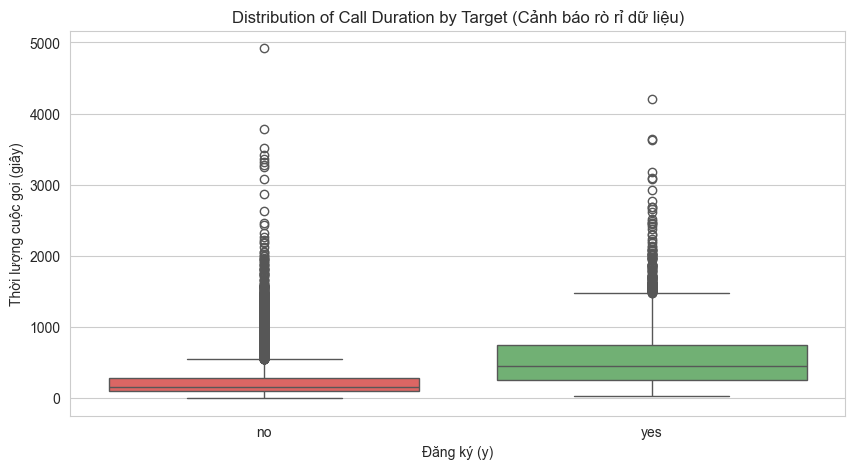

Số lượng cột trước khi xóa: 21
Số lượng cột sau khi xóa 'duration': 20


In [74]:
# Trực quan hóa sự nguy hiểm của biến duration
plt.figure(figsize=(10, 5))
sns.boxplot(x='y', y='duration', data=df, palette=["#EF5350", "#66BB6A"])
plt.title("Distribution of Call Duration by Target (Cảnh báo rò rỉ dữ liệu)")
plt.xlabel("Đăng ký (y)")
plt.ylabel("Thời lượng cuộc gọi (giây)")
plt.show()

# Hành động: Xóa bỏ biến duration khỏi tập dữ liệu để chuẩn bị cho Modeling
print(f"Số lượng cột trước khi xóa: {df.shape[1]}")
df_clean = df.drop(columns=['duration']).copy()
print(f"Số lượng cột sau khi xóa 'duration': {df_clean.shape[1]}")

---
## Phần 2: Phân tích thuộc tính 

### 2.1. Hiểu cái chung


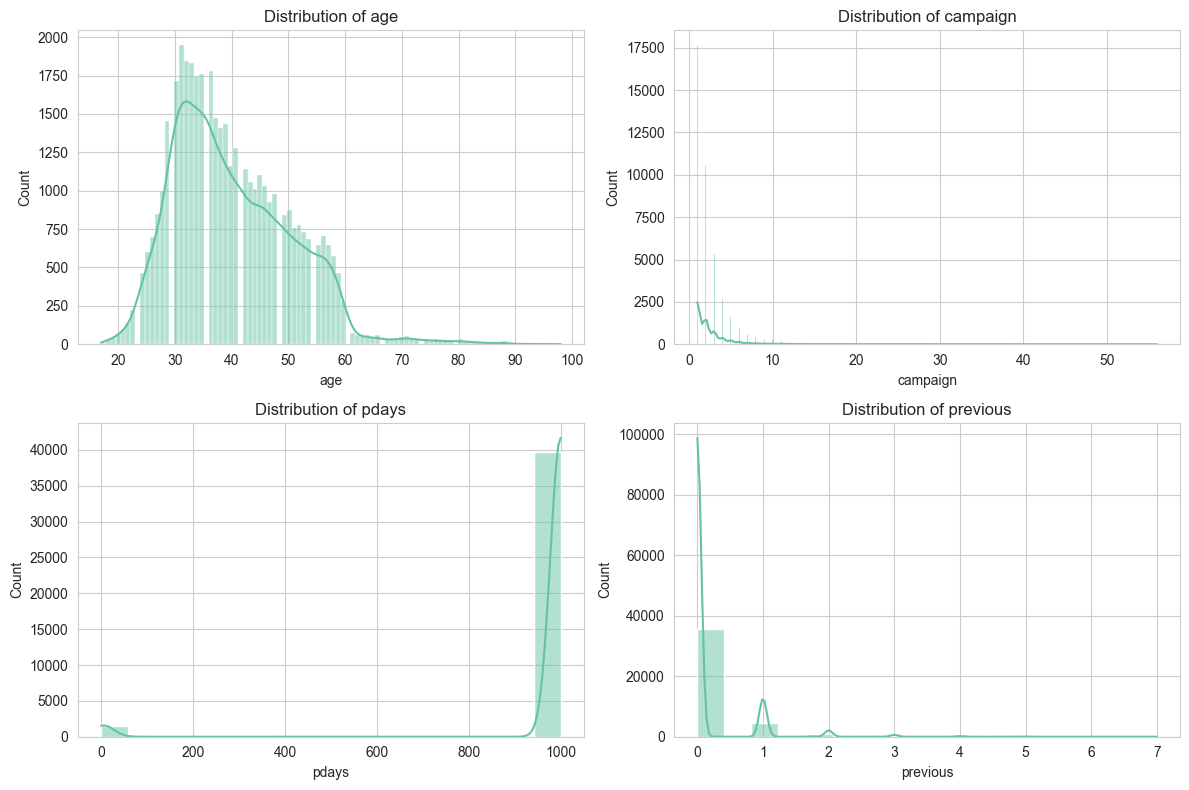

In [75]:
num_cols = ['age', 'campaign', 'pdays', 'previous']

fig, axes = plt.subplots(2,2, figsize=(12,8))

for i, col in enumerate(num_cols):
    ax = axes[i//2, i%2]
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

## Nhận định chung

`Age`:
  - Phân bố tập trung ở nhóm trung niên

`Campaign`:
  - Phần lớn khách hàng chỉ bị contact 1–2 lần

`Previous`:
  - Đa số khách chưa từng được contact trước đó


> `Hành vi khách hàng có thể bị ảnh hưởng bởi tần suất contact`

### 2.2. So sánh `YES` và `NO`

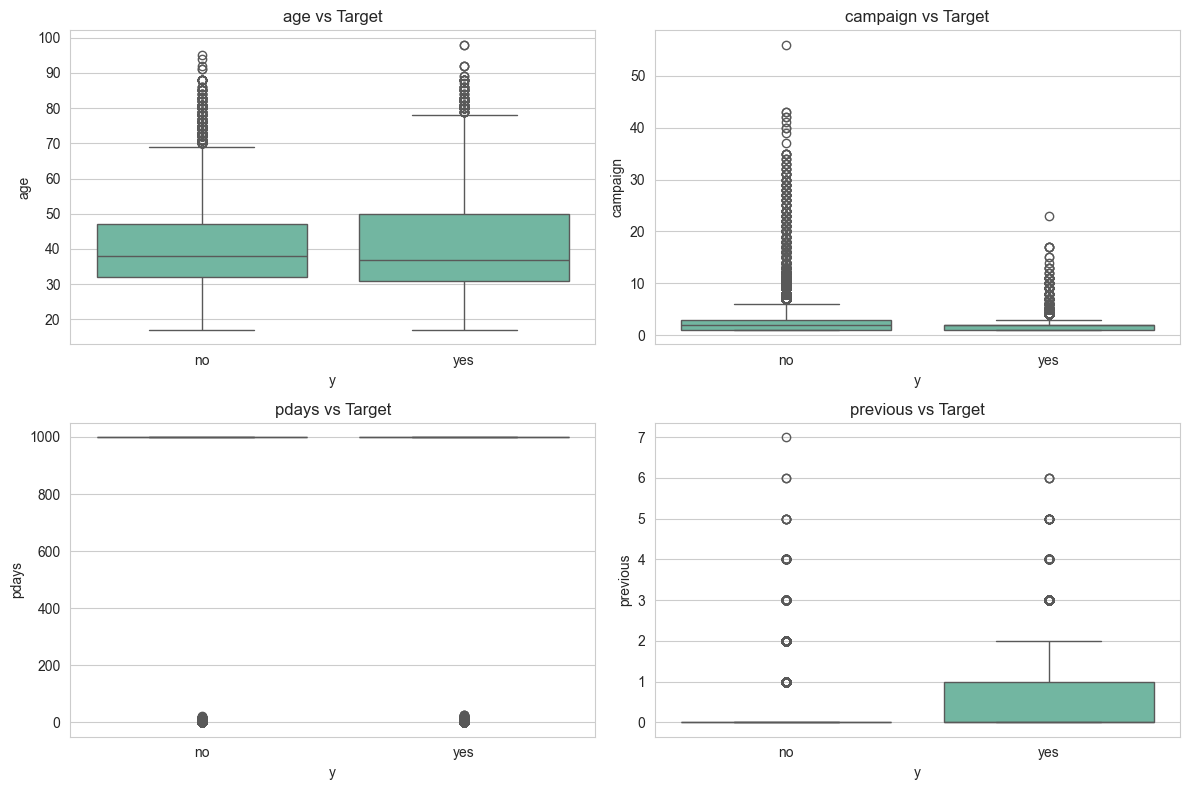

In [76]:
fig, axes = plt.subplots(2,2, figsize=(12,8))

for i, col in enumerate(num_cols):
    ax = axes[i//2, i%2]
    sns.boxplot(x='y', y=col, data=df, ax=ax)
    ax.set_title(f"{col} vs Target")

plt.tight_layout()
plt.show()

## Comparison Insights

- Campaign:
  - Nhóm "Yes" có số lần contact thấp hơn

- Previous:
  - Khách đã từng contact có khả năng convert cao hơn

>Đây có thể không phải quan hệ nhân quả

→ Có khả năng:
`Khách hàng tiềm năng cao được liên hệ nhiều hơn`

Previous nên được hiểu là:
> Signal (dấu hiệu), không phải nguyên nhân

`Hypothesis:` Gọi quá nhiều có thể gây phản tác dụng

<Axes: xlabel='poutcome', ylabel='previous'>

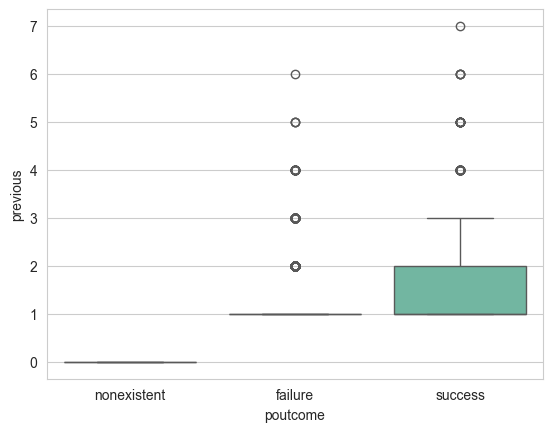

In [77]:
sns.boxplot(x='poutcome', y='previous', data=df)

### 🔬 Xác nhận thống kê: Campaign Effect

Để kiểm chứng giả thuyết rằng số lần contact ảnh hưởng đến conversion, ta thực hiện kiểm định t-test:

>- H0: Không có sự khác biệt về conversion giữa nhóm contact ít và nhiều
>- H1: Có sự khác biệt


In [78]:
low_contact = df[df['campaign'] <= 3]['y'].apply(lambda x: 1 if x=='yes' else 0)
high_contact = df[df['campaign'] > 3]['y'].apply(lambda x: 1 if x=='yes' else 0)

from scipy.stats import ttest_ind
stat, p = ttest_ind(low_contact, high_contact)

print("p-value:", p)

p-value: 1.736940049764521e-34


### Kết luận kiểm định

- `p-value < 0.05` → bác bỏ H0
- Có sự khác biệt có ý nghĩa thống kê

> Số lần contact thực sự ảnh hưởng đến khả năng chuyển đổi

💡 Insight:
Over-contact không chỉ là cảm nhận — mà đã được xác nhận bằng dữ liệu

### 2.3. Phân tích tương tác
>Không chỉ từng feature riêng lẻ, mà sự kết hợp giữa các feature mới quyết định hành vi khách hàng

C:\Users\User\AppData\Local\Temp\ipykernel_25956\575399785.py:20: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(


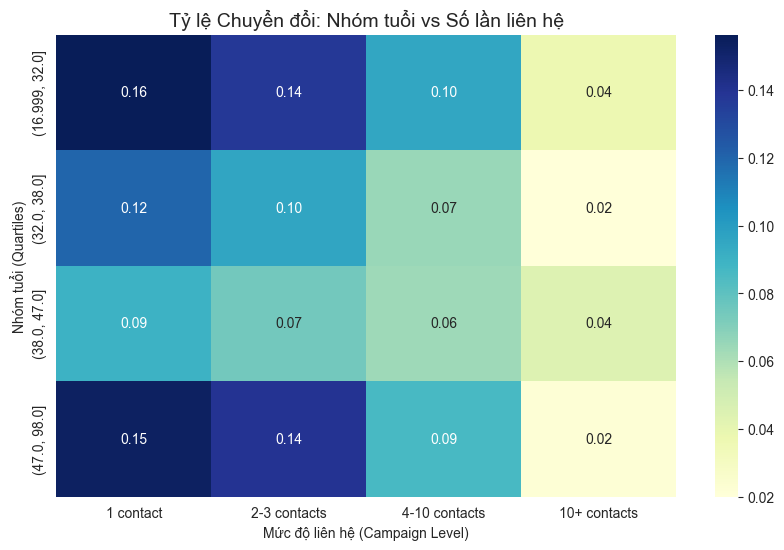

In [79]:
# 1. Định nghĩa hàm phân nhóm campaign
def categorize_campaign(n):
    if n == 1: return '1 contact'
    elif 2 <= n <= 3: return '2-3 contacts'
    elif 4 <= n <= 10: return '4-10 contacts'
    else: return '10+ contacts'

# 2. Tạo cột mới
def add_features(df):
    df = df.copy()
    
    df['campaign_group'] = df['campaign'].apply(categorize_campaign)
    df['age_group'] = pd.qcut(df['age'], 4, duplicates='drop')
    
    return df

# 3. Tạo Pivot Table tính tỷ lệ Convert (Yes)
df_eda = add_features(df)

pivot = pd.pivot_table(
    df_eda,
    values='y',
    index='age_group',
    columns='campaign_group',
    aggfunc=lambda x: (x == 'yes').mean()
)

# Sắp xếp lại thứ tự cột cho logic
col_order = ['1 contact', '2-3 contacts', '4-10 contacts', '10+ contacts']
pivot = pivot[col_order]

# 4. Vẽ Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='YlGnBu')

plt.title("Tỷ lệ Chuyển đổi: Nhóm tuổi vs Số lần liên hệ", fontsize=14)
plt.xlabel("Mức độ liên hệ (Campaign Level)")
plt.ylabel("Nhóm tuổi (Quartiles)")
plt.show()

### 2.4. Phân tích nhóm Nhân khẩu học (Demographics)
> **Câu hỏi:** Nghề nghiệp (Job) hoặc Học vấn (Education) nào có tỷ lệ chuyển đổi (Conversion Rate) cao nhất?

Để trực quan hóa, chúng ta sẽ sử dụng biểu đồ **Stacked Bar Chart 100%**. Biểu đồ này giúp loại bỏ sự chênh lệch về số lượng tuyệt đối giữa các nhóm, tập trung hoàn toàn vào **tỷ lệ % Convert** của từng nhóm.

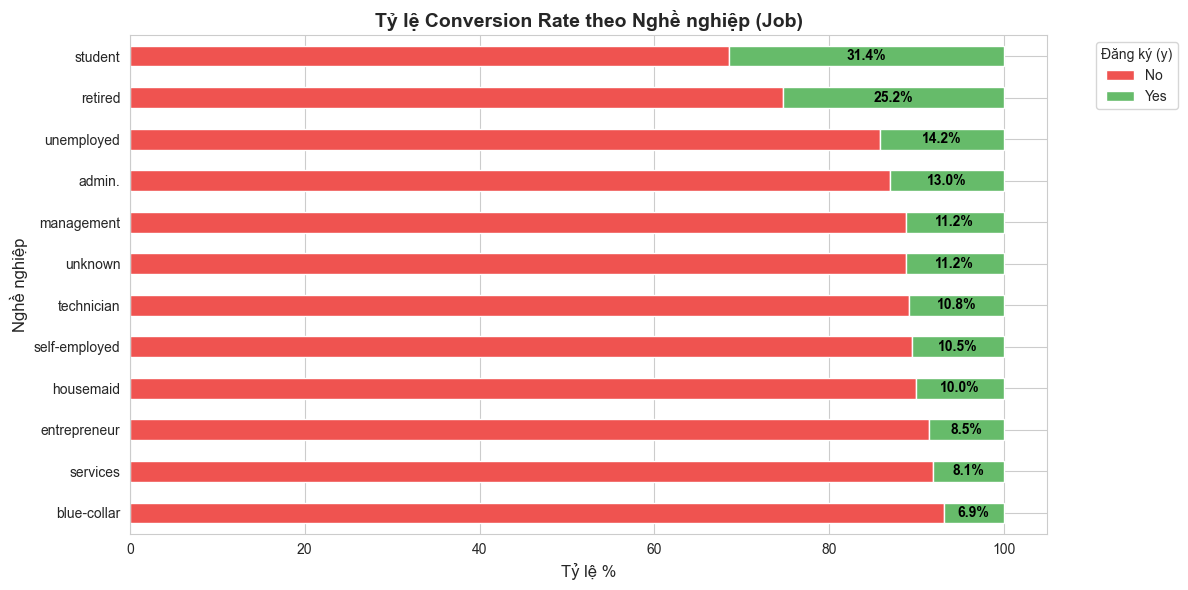

In [80]:
# Tính toán tỷ lệ phần trăm Target theo từng nhóm Job
job_target_pct = pd.crosstab(df['job'], df['y'], normalize='index')*100
job_target_pct = job_target_pct.sort_values(by='yes', ascending=True)

# Vẽ biểu đồ Stacked Bar 100%
fig, ax = plt.subplots(figsize=(12,6))

job_target_pct.plot(kind='barh', stacked=True, color=['#EF5350', '#66BB6A'], ax=ax, edgecolor='white')

ax.set_title('Tỷ lệ Conversion Rate theo Nghề nghiệp (Job)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tỷ lệ %', fontsize=12)
ax.set_ylabel('Nghề nghiệp', fontsize=12)
ax.legend(['No', 'Yes'], title='Đăng ký (y)', loc='upper right', bbox_to_anchor=(1.15, 1))

# Thêm text % vào biểu đồ cho phần "Yes"
for n, x in enumerate([*job_target_pct.index.values]):
    yes_pct = job_target_pct.loc[x, 'yes']
    ax.text(100 - (yes_pct/2), n, f'{yes_pct:.1f}%', color='black', ha='center', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### Nhận định: Nhóm khách hàng mục tiêu theo nghề nghiệp
- **Sinh viên (Student) và Người về hưu (Retired)** có tỷ lệ convert cao vượt trội `(gần 25-31%)`.
- **Blue-collar (Công nhân)** và **Services (Dịch vụ)** có tỷ lệ từ chối cao nhất.
> **Giả thuyết:** Sinh viên có thể cần các gói vay đi học/thẻ tín dụng sinh viên, trong khi người về hưu quan tâm đến gửi tiết kiệm. Cần thiết kế gói sản phẩm riêng (Personalized offers) thay vì gọi điện chung chung.

### 🔬 Xác nhận thống kê: Job vs Conversion

In [81]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['job'], df['y'])
chi2, p, _, _ = chi2_contingency(contingency)

print("p-value:", p)

p-value: 4.189763287563623e-199


>p-value < 0.05 → nghề nghiệp có ảnh hưởng đến conversion

Nhận địng về `Student / Retired` là đáng tin cậy

---
### 2.5. Phân tích nhóm Yếu tố Vĩ mô (Socio-Economic)
Các biến số kinh tế vĩ mô (vd: tỷ giá Euribor, tỷ lệ việc làm, chỉ số giá tiêu dùng) thường có độ tương quan (Correlation) rất cao với nhau (Multicollinearity - Đa cộng tuyến). Điều này có thể làm nhiễu một số mô hình học máy (như Logistic Regression).

>Chúng ta sẽ dùng **Heatmap** để kiểm tra mức độ tương quan của cụm biến này.

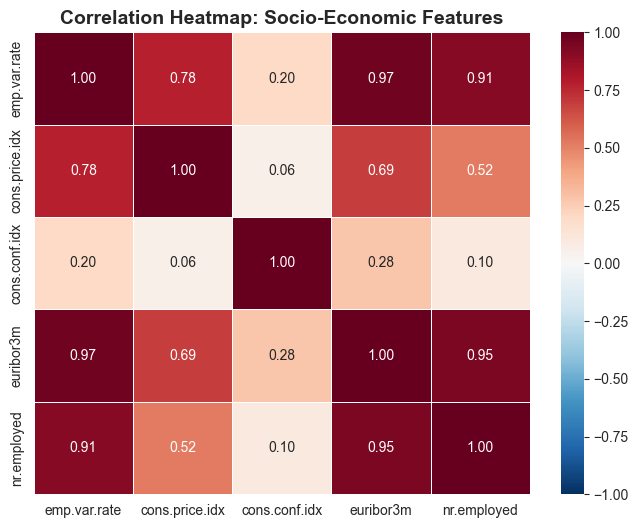

In [82]:
# Chọn các biến kinh tế vĩ mô
socio_economic_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

# Tính ma trận tương quan
corr_matrix = df_clean[socio_economic_cols].corr()

# Vẽ Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Socio-Economic Features", fontsize=14, fontweight='bold')
plt.show()

### Nhận định: Đa cộng tuyến (Multicollinearity)
- `euribor3m` (Lãi suất liên ngân hàng), `emp.var.rate` (Tỷ lệ thay đổi việc làm) và `nr.employed` (Số lượng lao động) có tương quan dương cực kỳ mạnh (gần như = 1).
- **Quyết định cho Modeling:** Các mô hình Tree-based (Random Forest, XGBoost) không bị ảnh hưởng nhiều bởi đa cộng tuyến. Tuy nhiên, nếu dùng Logistic Regression, chúng ta sẽ cần loại bỏ bớt 2 trong 3 biến này để tránh làm mất ổn định trọng số của mô hình.

---
## Phần 3: Tiền xử lý dữ liệu (Preprocessing)
Để đưa dữ liệu vào mô hình Machine Learning, chúng ta cần:
1. `Mã hóa (Encoding):` Chuyển các biến chữ (categorical) thành số.
2. `Chuẩn hóa (Scaling):` Đưa các biến số về cùng một đơn vị (đặc biệt quan trọng cho Clustering).
3. `Chia tập dữ liệu:` Tách tập Train (để học) và tập Test (để đánh giá khách quan).

In [83]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_clean = df_clean.drop(columns=['default'])

# 1.Mã hóa biến mục tiêu y (y,n = 1,0)
le = LabelEncoder()
df_clean['y'] = le.fit_transform(df_clean['y'])

# 2. Xử lý các cột phụ đã tạo để phân tích 
# Chúng ta sẽ giữ lại df_clean gốc cho modeling, xóa các cột group phụ
df_ml = df_clean.drop(columns=['campaign_group', 'age_group'], errors='ignore')

# 3. One-hot Encoding cho các biến phân loại
df_ml = pd.get_dummies(df_ml, drop_first=True)

# 4. Chia tập Train/ Test (8/2) - Stratify để giữ tỷ lệ imbalance
X = df_ml.drop('y', axis=1)
y = df_ml['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Chuẩn hóa dữ liệu số (StandardScaler)
scaler = StandardScaler()
# Chỉ scale các cột số gốc (không phải các cột dummy 0-1)
num_cols_to_scale = ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 
                     'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

X_train[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])
X_test[num_cols_to_scale] = scaler.transform(X_test[num_cols_to_scale])

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")

Kích thước tập Train: (32950, 50)
Kích thước tập Test: (8238, 50)


---
## Phần 4: Phân cụm khách hàng (Customer Segmentation)
> **Mục tiêu:** Trả lời câu hỏi số 3: "Có thể chia nhóm khách hàng không?". 

Chúng ta sẽ sử dụng thuật toán **K-Means** trên các thuộc tính nhân khẩu học và kinh tế để tìm ra các "chân dung khách hàng" (Personas) đặc trưng.

>**Clusters có thể được dùng để:**
>- Cá nhân hóa nội dung gọi điện
>- Phân bổ telesale theo nhóm khách hàng

,age,euribor3m,emp.var.rate,previous,conversion_rate
cluster,,,,,
0,-0.071937,-1.388679,-1.348589,-0.350127,0.208673
1,0.016024,0.701622,0.680148,-0.349848,0.049566
2,0.032904,-1.230378,-1.189065,2.194713,0.267049


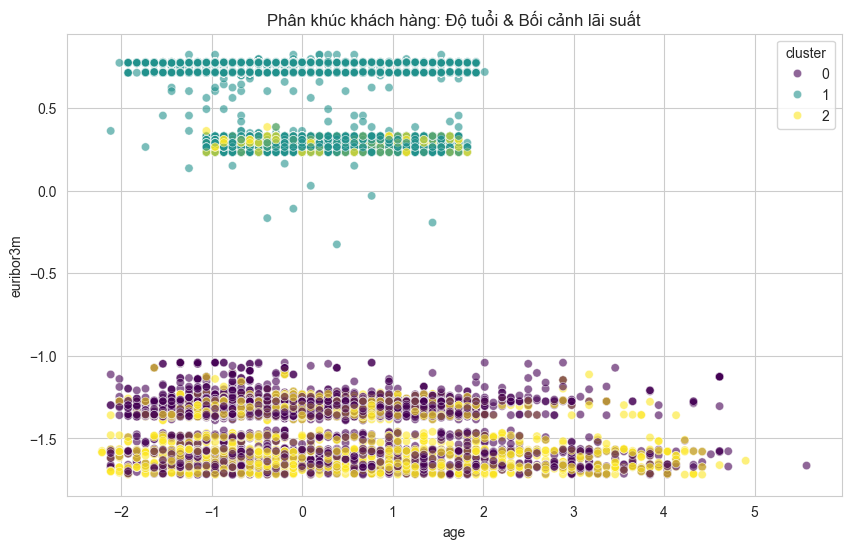

In [84]:
from sklearn.cluster import KMeans

# Sử dụng dữ liệu đã chuẩn hóa để phân cụm
# Chúng ta chọn các đặc điểm chính về khách hàng và bối cảnh 
cluster_features = ['age', 'euribor3m', 'emp.var.rate', 'previous']
X_cluster = X_train[cluster_features]

# Dùng Elbow Method để chọn K (ở đây giả định K=3 để dễ giải thích)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
X_train['cluster'] = kmeans.fit_predict(X_cluster)

# Phân tích đặc điểm từng cụm 
cluster_summary = X_train.groupby('cluster')[cluster_features].mean()
# Thêm tỷ lệ conversion thực tế của từng cụm
cluster_summary['conversion_rate'] = y_train.groupby(X_train['cluster']).mean()

display(cluster_summary)

# Trực quan hóa phân cụm 
plt.figure(figsize=(10,6))
sns.scatterplot(data=X_train, x='age', y='euribor3m', hue='cluster', palette='viridis', alpha=0.6)
plt.title("Phân khúc khách hàng: Độ tuổi & Bối cảnh lãi suất")
plt.show()

---
## Phần 5: Xây dựng mô hình dự đoán 
>Lý do chọn Random Forest

Dữ liệu có:
- Nhiều biến categorical đã encode
- Non-linear relationships (hành vi khách hàng không tuyến tính)
- Multicollinearity mạnh (euribor3m ~ nr.employed ~ emp.var.rate)

>Random Forest phù hợp vì:

- Không bị ảnh hưởng bởi multicollinearity
- Bắt được quan hệ phi tuyến
- Robust với noise
- Không cần scaling quá nhiều

>Ngoài ra:

Dataset bị imbalance nặng

→ Dùng: `class_weight='balanced`

>Vấn đề của RF thường:

- Overconfident (đoán 0.9 nhưng thực tế ~0.6)
- Không dùng trực tiếp cho decision business

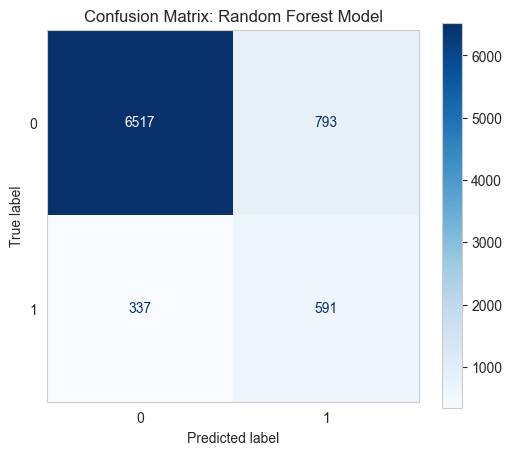

              precision    recall  f1-score   support

           0       0.95      0.89      0.92      7310
           1       0.43      0.64      0.51       928

    accuracy                           0.86      8238
   macro avg       0.69      0.76      0.72      8238
weighted avg       0.89      0.86      0.87      8238



In [85]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Chuẩn bị dữ liệu huấn luyện
# Xóa cột cluster (nếu có) để mô hình không dựa vào kết quả phân cụm trước đó
X_train_model = X_train.drop(columns=['cluster'], errors='ignore')

# 2. Khởi tạo và huấn luyện
rf = RandomForestClassifier(n_estimators=100, max_depth=10,
                            class_weight='balanced', random_state=42)
rf.fit(X_train_model, y_train)

# 3. Dự đoán trên tập test
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

# 4. Trực quan hóa Ma trận nhầm lẫn (Fix lỗi t_test)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix: Random Forest Model')
plt.grid(False)
plt.show()

# 5. In báo cáo đánh giá
print(classification_report(y_test, y_pred))

>Lý do dùng Calibration
Trong BUSINESS:
- Không chỉ cần YES / NO
- Cần `XÁC SUẤT CHÍNH XÁC` để ra quyết định tài chính

In [86]:
from sklearn.calibration import CalibratedClassifierCV

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

calibrated_rf = CalibratedClassifierCV(rf, method='isotonic', cv=3)
calibrated_rf.fit(X_train_model, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",RandomForestC...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'

Trong business:
- Không chỉ cần biết YES/NO
- Mà cần biết `xác suất` để ưu tiên khách hàng

>Đây là nền tảng của Lead Scoring

### Kết luận
`Random Forest` được chọn để học pattern phức tạp,
nhưng do xác suất đầu ra không đáng tin cậy,
nên sử dụng `Calibration` để biến output thành xác suất có ý nghĩa trong `quyết định tài chính`

### ⚠️ Hạn chế của mô hình

- Mô hình được huấn luyện trên dữ liệu chiến dịch trong quá khứ → có thể không còn phù hợp nếu hành vi khách hàng thay đổi
- Các biến kinh tế vĩ mô (lãi suất, CPI, ...) có thể biến động theo thời gian
- Calibration giả định phân phối dữ liệu ổn định

> Do đó, cần:
>- Cập nhật (retrain) mô hình định kỳ
>- Theo dõi performance theo thời gian

### `Tại sao không chọn Logistic Regression?`

Logistic Regression đã được cân nhắc, tuy nhiên không được chọn vì:

- Dữ liệu có nhiều mối quan hệ phi tuyến (non-linear)
- Các biến kinh tế có thể có tương tác phức tạp
- Có hiện tượng đa cộng tuyến (multicollinearity)

Trong khi đó:

- Random Forest xử lý tốt quan hệ phi tuyến
- Ít bị ảnh hưởng bởi multicollinearity
- Cho performance ổn định hơn

>Vì vậy, Random Forest phù hợp hơn cho bài toán này

In [87]:
# Lưu mô hình 
import joblib

joblib.dump(calibrated_rf, "models/model.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(X_train_model.columns, "models/columns.pkl")

['models/columns.pkl']

---
## Phần 6: Quyết định & Hành động (Decision & Action)

>### Decision Rule (Profit-based)

Chỉ nên gọi khách hàng khi:

`Expected Profit = P(convert) × Revenue - Cost_call > 0`


### 6.1. Yếu tố nào ảnh hưởng mạnh nhất?
### Tối ưu hóa ngưỡng

Thay vì chọn threshold tùy ý (0.3), ta nên dựa vào business:

Threshold = Cost / Revenue

Ví dụ:
- Cost_call = $5
- Revenue = $100

→ Threshold = 5 / 100 = 0.05

> Chỉ cần xác suất > 5% là có thể có lợi nhuận
>- Đây là phần quan trọng nhất để trả lời câu hỏi: `"Làm sao để tối ưu campaign?"`. 
>Chúng ta sẽ xem xét các thuộc tính mà mô hình đánh giá là quan trọng nhất.

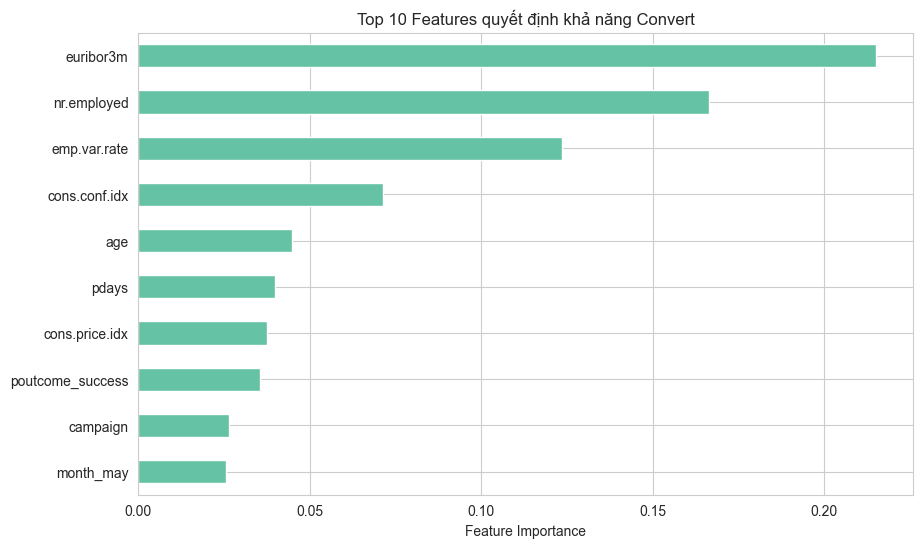

In [88]:
import numpy as np

importances = np.mean(
    [clf.estimator.feature_importances_ for clf in calibrated_rf.calibrated_classifiers_],
    axis=0
)

feat_importance = (
    pd.Series(importances, index=X_train_model.columns)
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
feat_importance.plot(kind='barh')
plt.gca().invert_yaxis()

plt.title("Top 10 Features quyết định khả năng Convert")
plt.xlabel("Feature Importance")

plt.show()

>- Feature importance được tính từ các mô hình `Random Forest` trước khi calibration.
>- Do CalibratedClassifierCV sử dụng nhiều mô hình (cross-validation),feature importance được lấy trung bình để đảm bảo tính ổn định.
>- `Lưu ý:` calibration không thay đổi feature importance, mà chỉ điều chỉnh xác suất đầu ra.

## Phân tích từ Top 10 Features:
Dựa vào biểu đồ trên:

1. **Yếu tố Vĩ mô `Euribor3m, nr.employed`:** Thường đứng đầu. Điều này cho thấy khách hàng cực kỳ nhạy cảm với tình hình kinh tế và lãi suất thị trường.
2. **Kinh nghiệm quá khứ `pdays, poutcome_success`:** Nếu khách hàng đã từng đồng ý ở chiến dịch trước, khả năng họ đồng ý lại là rất cao. Đây là nhóm "khách hàng thân thiết".
3. **Độ tuổi `age`:** Tuổi tác ảnh hưởng đến nhu cầu tài chính (như chúng ta đã thấy ở phần phân tích Sinh viên/Người về hưu).

**Hành động tiếp theo:**
- Ngân hàng nên tích hợp mô hình này vào phần mềm của nhân viên Telesales. 
- Hệ thống sẽ tự động xếp hạng danh sách khách hàng từ cao xuống thấp. Nhân viên chỉ cần tập trung gọi cho Top 20% danh sách này để đạt được 80% hiệu quả mong muốn.

### 6.2. Hệ thống cảnh báo sớm (EWS)

### Bản đồ hành động 

| Action | Thực hiện |
|------|--------|
| CALL | `Gửi cho telesales senior` |
| SKIP | `Không gọi, chuyển sang email marketing` |
| STOP_CONTACT | `Ngừng hoàn toàn, tránh spam` |
| REVIEW |`Gửi cho team kiểm tra thêm` |



>### Mục tiêu:

Xây dựng hệ thống cảnh báo sớm để:
- Tránh lãng phí tài nguyên
- Tối ưu hiệu quả chiến dịch
- Hỗ trợ ra quyết định real-time

>### Các loại cảnh báo

#### 1. Over-contact Warning
- Điều kiện:
  - campaign > 3
  - P(convert) thấp
→ Dừng liên hệ

#### 2. Low-quality Lead Warning
- P(convert) < Threshold
→ Negative expected profit → SKIP

#### 3. Negative ROI Warning
- Điều kiện:
  - Expected Profit < 0
→ Bỏ qua khách hàng

In [89]:
# Business parameters (single source of truth)
CALL_COST = 5       
REVENUE   = 100     
THRESHOLD = CALL_COST / REVENUE   

NUMERIC_COLS = [
    'age', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'nr.employed'
]


def preprocess_input(input_df):
    df = input_df.copy()

    df_encoded = pd.get_dummies(df)
    df_encoded = df_encoded.reindex(columns=X_train_model.columns, fill_value=0)

    for col in NUMERIC_COLS:
        if col not in df_encoded.columns:
            df_encoded[col] = 0

    df_encoded[NUMERIC_COLS] = scaler.transform(df_encoded[NUMERIC_COLS])

    return df_encoded


def decision_engine(prob, campaign, cost=CALL_COST, revenue=REVENUE):
    threshold       = cost / revenue            # unified formula
    expected_profit = prob * revenue - cost

    if campaign > 3 and prob < threshold:
        return 'STOP_CONTACT', 'Over-contact + negative ROI', expected_profit

    if prob < threshold:
        return 'SKIP', 'Negative expected profit', expected_profit

    if prob >= threshold:
        return 'CALL', 'Positive expected profit', expected_profit

    return 'REVIEW', 'Edge case - manual review', expected_profit


def predict_customer(input_df, cost=CALL_COST, revenue=REVENUE):
    # 1. Preprocess (OHE + column alignment)
    processed = preprocess_input(input_df)

    # 2. Calibrated probability from trained Random Forest
    prob = float(calibrated_rf.predict_proba(processed)[:, 1][0])

    # 3. Business decision (profit-based, unified threshold)
    campaign = int(input_df['campaign'].values[0])
    action, warning, expected_profit = decision_engine(prob, campaign, cost, revenue)

    return {
        'probability'    : round(prob, 4),
        'action'         : action,
        'warning'        : warning,
        'expected_profit': round(expected_profit, 2)
    }


print('Production pipeline loaded.')
print(f'  Threshold = {THRESHOLD:.2%}  (cost={CALL_COST}$ / revenue={REVENUE}$)')


Production pipeline loaded.
  Threshold = 5.00%  (cost=5$ / revenue=100$)


In [90]:
# ======================
# PREPARE DATA
# ======================
df_batch = df_clean.loc[X_test.index].drop(columns=['y'])

# ======================
# PREDICT ALL CUSTOMERS
# ======================
results = df_batch.apply(
    lambda row: predict_customer(row.to_frame().T),
    axis=1
)

# Convert → DataFrame
df_results = pd.DataFrame(list(results))

# ======================
# ADD BUSINESS METRICS
# ======================
df_results['expected_profit'] = df_results['probability'] * REVENUE - CALL_COST

# Ranking khách hàng
df_results['rank'] = df_results['probability'].rank(ascending=False)

# Segment khách hàng
df_results['segment'] = pd.qcut(
    df_results['probability'],
    4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

# Sort theo khách tốt nhất
df_results = df_results.sort_values(by='probability', ascending=False)

# ======================
# QUICK VIEW
# ======================
print(df_results.head())
print(df_results['action'].value_counts())

      probability action                   warning  expected_profit  rank  \
4500       0.2698   CALL  Positive expected profit            21.98   1.0   
3240       0.2614   CALL  Positive expected profit            21.14   4.5   
7474       0.2614   CALL  Positive expected profit            21.14   4.5   
5896       0.2614   CALL  Positive expected profit            21.14   4.5   
4622       0.2614   CALL  Positive expected profit            21.14   4.5   

        segment  
4500  Very High  
3240  Very High  
7474  Very High  
5896  Very High  
4622  Very High  
action
CALL    8238
Name: count, dtype: int64


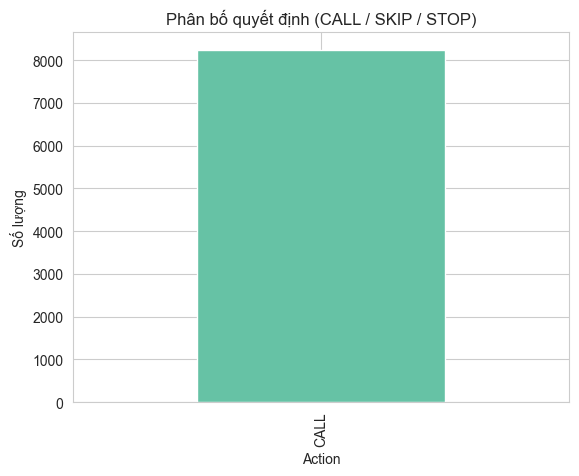

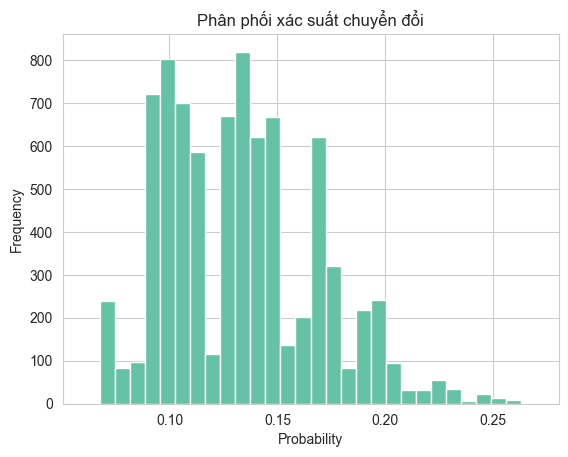

C:\Users\User\AppData\Local\Temp\ipykernel_25956\1426773164.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_results.groupby('segment')['expected_profit'].mean().plot(kind='bar')


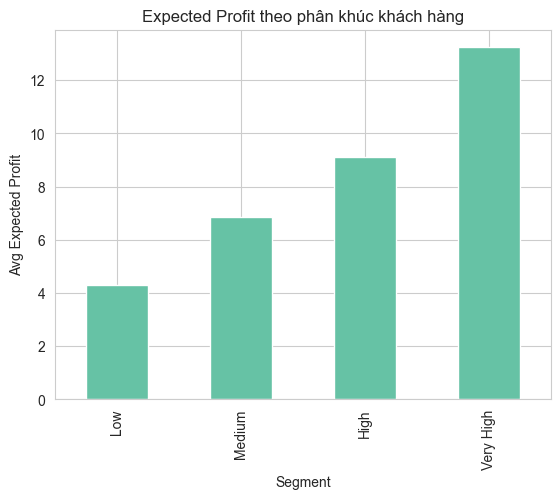

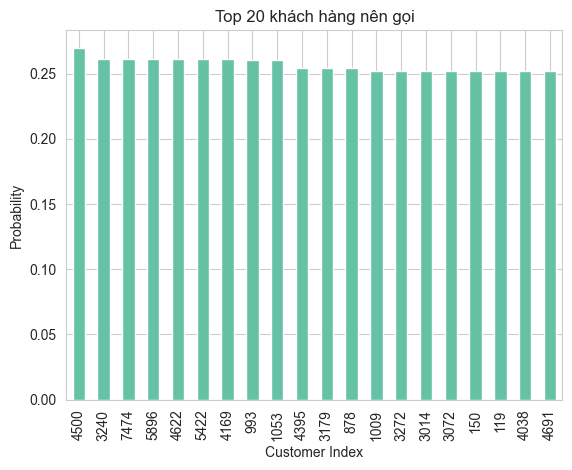

In [91]:
# 1. Phân bố hành động
import matplotlib.pyplot as plt

plt.figure()
df_results['action'].value_counts().plot(kind='bar')

plt.title("Phân bố quyết định (CALL / SKIP / STOP)")
plt.xlabel("Action")
plt.ylabel("Số lượng")

plt.show()

# 2. Phân phối xác suất
plt.figure()
df_results['probability'].plot(kind='hist', bins=30)

plt.title("Phân phối xác suất chuyển đổi")
plt.xlabel("Probability")
plt.ylabel("Frequency")

plt.show()

# 3. Profit theo nhóm khách
plt.figure()
df_results.groupby('segment')['expected_profit'].mean().plot(kind='bar')

plt.title("Expected Profit theo phân khúc khách hàng")
plt.xlabel("Segment")
plt.ylabel("Avg Expected Profit")

plt.show()

# 4. Top khách hàng tiềm năng
top_customers = df_results[df_results['action'] == 'CALL'].head(20)

plt.figure()
top_customers['probability'].plot(kind='bar')

plt.title("Top 20 khách hàng nên gọi")
plt.xlabel("Customer Index")
plt.ylabel("Probability")

plt.show()


### Nhận định: 
- Hệ thống phân loại khách hàng thành 4 nhóm rõ ràng
- Nhóm “Very High” mang lại expected profit cao nhất
- Phần lớn khách hàng nằm ở nhóm Low → nên tránh gọi
- Chiến lược tối ưu:
    - Chỉ tập trung vào top 20–30% khách hàng

>### TEST

In [92]:
new_customer = pd.DataFrame([{
    'age': 35,
    'job': 'technician',
    'marital': 'married',
    'education': 'university.degree',
    'housing': 'yes',
    'loan': 'no',
    'contact': 'cellular',
    'month': 'may',
    'day_of_week': 'mon',
    'campaign': 2,
    'pdays': 999,
    'previous': 0,
    'poutcome': 'nonexistent',
    'emp.var.rate': -1.8,
    'cons.price.idx': 92.893,
    'cons.conf.idx': -46.2,
    'euribor3m': 1.313,
    'nr.employed': 5099.1
}])

predict_customer(new_customer)

{'probability': 0.0764,
 'action': 'CALL',
 'warning': 'Positive expected profit',
 'expected_profit': 2.64}

## Phần 7: Lợi nhuận
### Phân tích lợi nhuận 

>Ước tính lợi nhuận ở trên dựa trên giả định:

- Mỗi khách hàng chuyển đổi mang lại doanh thu cố định
- Chi phí gọi điện là không đổi

>Tuy nhiên trong thực tế:

- Doanh thu có thể khác nhau giữa các khách hàng
- Chi phí có thể thay đổi theo kênh hoặc thời gian
- Việc giảm số cuộc gọi không hiệu quả giúp tối ưu nguồn lực

> Do đó, mô hình không chỉ tăng doanh thu mà còn giúp tối ưu hiệu quả vận hành (operational efficiency)

# Kết luận và Hành động

Dựa trên kết quả từ Mô hình và EDA, chúng ta có 3 chiến lược chính:

### 1. "Target Right" - Nhắm đúng đối tượng
- **Yếu tố Vĩ mô:** `euribor3m` và `emp.var.rate` là những yếu tố hàng đầu. Ngân hàng nên đẩy mạnh chiến dịch khi lãi suất thị trường có xu hướng thấp hoặc ổn định.
- **Nhóm tiềm năng:** Tập trung vào khách hàng đã từng có kết quả `poutcome_success` từ các chiến dịch trước.

### 2. "Resource Optimization" - Tối ưu nguồn lực
- **Giới hạn Campaign:** Dựa trên phân tích, không nên gọi quá 3 lần cho cùng một khách hàng. Hiệu quả giảm mạnh sau ngưỡng này, gây lãng phí chi phí nhân sự.
- **Lead Scoring:** Sử dụng mô hình dự báo để chấm điểm khách hàng. Chỉ chuyển các khách hàng  có Expected Profit > 0 `tương đương probability > threshold` cho đội Telesales chuyên nghiệp.

### 3. "Customer Experience" - Trải nghiệm khách hàng
- Nhóm **Sinh viên `Student`** và **Người về hưu `Retired`** có tỷ lệ chuyển đổi tự nhiên cao nhất. Cần xây dựng gói sản phẩm chuyên biệt (ví dụ: tiết kiệm hưu trí, thẻ tín dụng sinh viên) thay vì các gói vay thông thường.

## Tổng kết 

>Mô hình không chỉ dự đoán khả năng chuyển đổi, mà còn hỗ trợ ra quyết định tối ưu lợi nhuận trong chiến dịch marketing.
---
